
# Using PCA on Toxic Molecule Data

In this notebook, we apply PCA to explore if there are any hidden patterns in the [Toxicity dataset](https://archive.ics.uci.edu/dataset/728/toxicity-2) from UC Irvine's Machine Learning Repository, and wheteher we can reduce this dataset to lower dimensions. This dataset was introduced in the paper *"Structure-based design and classifications of small molecules regulating the circadian rhythm period"* (Gül et al., 2021, Scientific Reports). This study aimed to design molecules to potentially regulate circardian rhythm, which is a biological process in humans that controls daily activity on a 24-hour cycle. 

The dataset contains data observations of 171 molecules that target functional domains of the protein CRY1, which is responsible for generating circadian rhythm. The dataset contains 1203 features, all of which are different molecular descriptors like atom counts, bond types, and electronegativity statistics. According to the summary page of this dataset on the UCI site, some of these features are redundant, which makes PCA a great tool here. The target variable in the data is whether a molecule is toxic or not to the CRY1 protein (and in turn circadian rhythm periods). In the dataset, there are 56 toxic molecules and 115 non-toxic molecules.

Our first goal in this notebook is to reduce the number of features in the Toxicity dataset by using PCA. This will hopefully yield a more manageable dataset with only the most important molecular descriptors. Then we will use a decision tree classifier, which is what the original researchers used to classify molecules, on both the raw and reduced datasets to classify whether a given molecule is toxic or not and determine if PCA helps the decision tree predict better.  

---

## Load and Scale Data

In [1]:
# Import relevant pacakges

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ml_package import PCA, DecisionTreeClassifier, KNN, StandardScaler
from ml_package.utils.preprocessing import train_test_split
from ml_package.utils import classification_metrics

In [2]:
# Load data
df = pd.read_csv('toxicity_data.csv')
X = df.drop(columns=['Class']).values 
y = df["Class"]

# Label encode y and convert to a NumPy array
y = df["Class"].map({"Toxic": 1, "NonToxic": 0}).values

print(f"Samples:  {X.shape[0]}")
print(f"Features: {X.shape[1]}")
print(f"Toxic (1):     {(y == 1).sum()}")
print(f"Non-toxic (0): {(y == 0).sum()}")
print(f"Class balance: {(y == 1).mean():.1%} toxic")

Samples:  171
Features: 1203
Toxic (1):     56
Non-toxic (0): 115
Class balance: 32.7% toxic


---

Standardization is applied before any modeling step. KNN uses Euclidean distance and PCA measures variance, making both are sensitive to feature scale. With 1203 molecular descriptors measured in different units and ranges, standardization is essential before we proceed.

---

In [3]:
# Standardize to zero mean, unit variance
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Run PCA on Feature Data

---

We first fit PCA on all components to inspect the variance spectrum.

---

In [4]:
# Fit full PCA
pca = PCA(n_components=min(X_scaled.shape))
pca.fit(X_scaled)

# Use the explained variance ratio method from the PCA class
evr = pca.explained_variance_ratio_
cum_evr = np.cumsum(evr)

# Find how many components to hit common thresholds
for threshold in [0.80, 0.90, 0.95]:
    n = np.searchsorted(cum_evr, threshold) + 1
    print(f"{threshold:.0%} variance explained by {n} components")

80% variance explained by 26 components
90% variance explained by 42 components
95% variance explained by 59 components


---

Our PCA fit shows that 80% of the feature variance is explained by only 26 components out of the full 1203. Thus, we were able to greatly reduce the dimensions of our dataset without compromising much information! The scree plot below displays the eigenvalues for each principal component. The height of each bar (the eigenvalue) shows how much variance is explained by that principal component.

---

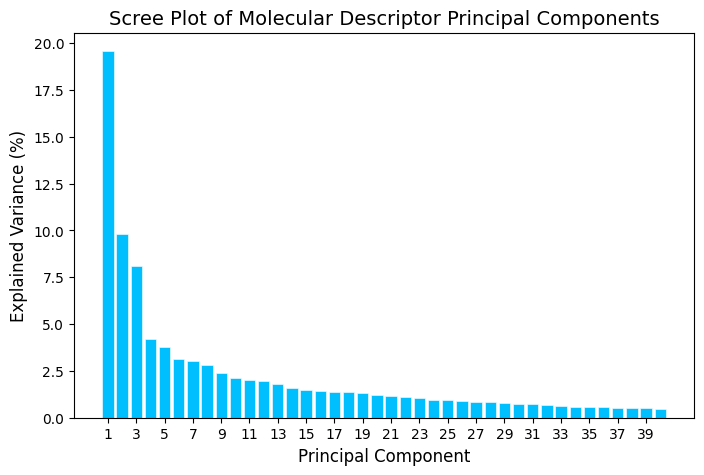

In [5]:
# Scree plot (first 40 components)
n_show = 40

plt.figure(figsize=(8, 5))

# Create the Scree Plot
plt.bar(range(1, n_show + 1), evr[:n_show] * 100, 
        color = "deepskyblue", edgecolor="white", linewidth=0.4)

plt.title("Scree Plot of Molecular Descriptor Principal Components", fontsize=14)
plt.xlabel("Principal Component", fontsize=12)
plt.ylabel("Explained Variance (%)", fontsize=12)
plt.xticks(range(1, n_show + 1, 2))
plt.show()

## Visualize the data in the PCA Space

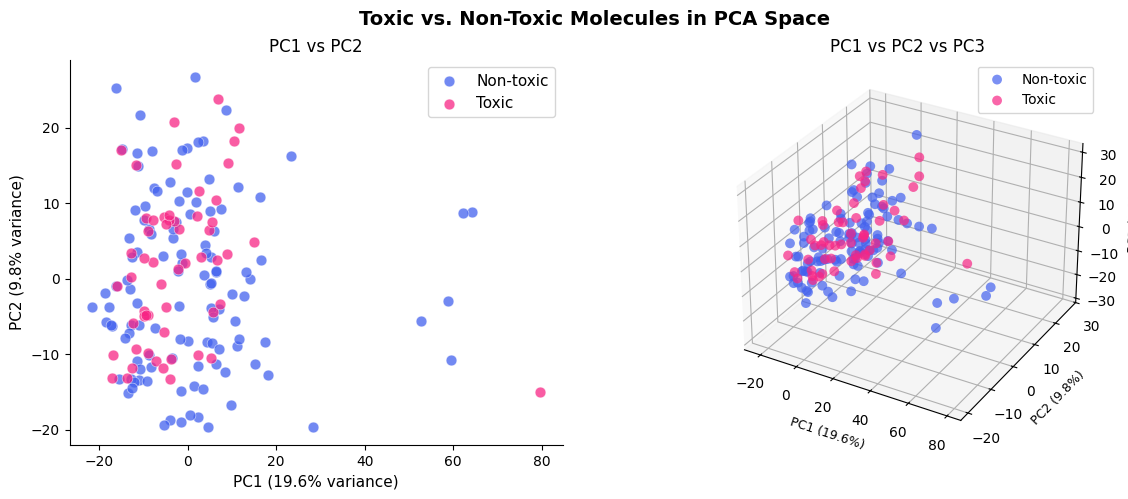

In [6]:
# Project onto first 2 and 3 PCs for visualization
pca2 = PCA(n_components=2)
X_2d = pca2.fit_transform(X_scaled)

pca3 = PCA(n_components=3)
X_3d = pca3.fit_transform(X_scaled)

COLORS = {0: "#4361EE", 1: "#F72585"}
LABELS = {0: "Non-toxic", 1: "Toxic"}

# ── Figure 2: 2D and 3D scatter plots ─────────────────────────────────────────
fig = plt.figure(figsize=(14, 5))
fig.suptitle("Toxic vs. Non-Toxic Molecules in PCA Space", fontsize=14,
             fontweight="bold")

# 2D scatter
ax1 = fig.add_subplot(1, 2, 1)
for cls in [0, 1]:
    mask = y == cls
    ax1.scatter(X_2d[mask, 0], X_2d[mask, 1],
                c=COLORS[cls], label=LABELS[cls],
                alpha=0.75, edgecolors="white", linewidth=0.4, s=60)
ax1.set_xlabel(f"PC1 ({evr[0]*100:.1f}% variance)", fontsize=11)
ax1.set_ylabel(f"PC2 ({evr[1]*100:.1f}% variance)", fontsize=11)
ax1.set_title("PC1 vs PC2", fontsize=12)
ax1.legend(fontsize=11)
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)

# 3D scatter
ax2 = fig.add_subplot(1, 2, 2, projection="3d")
for cls in [0, 1]:
    mask = y == cls
    ax2.scatter(X_3d[mask, 0], X_3d[mask, 1], X_3d[mask, 2],
                c=COLORS[cls], label=LABELS[cls],
                alpha=0.7, edgecolors="none", s=50)
ax2.set_xlabel(f"PC1 ({evr[0]*100:.1f}%)", fontsize=9)
ax2.set_ylabel(f"PC2 ({evr[1]*100:.1f}%)", fontsize=9)
ax2.set_zlabel(f"PC3 ({evr[2]*100:.1f}%)", fontsize=9)
ax2.set_title("PC1 vs PC2 vs PC3", fontsize=12)
ax2.legend(fontsize=10)

plt.show()

---

The graphs above show that the two classes are not cleanly linearly separable in the first two principal components. PC3 begins to reveal some additional separation, which represents additional explained variance. For this example, we will proceed with the 26 principal components that explained 80% of our fetaure data's variance when running KNN.

---

## Comparison of DecisionTreeClassifier on the Raw and Reduced Data

The next part of this notebook will compare how fitting a decision tree classifier of the molecule observations performs on both the raw data and the reduced-dimensions data. Before proceeding, however, we first split the data into train and test sets.

---

In [7]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.25, random_state=42, stratify=y)

# Apply PCA (fit on train only, transform both)
pca = PCA(n_components=26)
pca.fit(X_train_raw)
X_train_pca = pca.transform(X_train_raw)
X_test_pca  = pca.transform(X_test_raw)

print(f"Train: {X_train_raw.shape[0]} samples  |  Test: {X_test_raw.shape[0]} samples")
print(f"PCA train shape: {X_train_pca.shape}")
print(f"PCA test shape:  {X_test_pca.shape}")

Train: 128 samples  |  Test: 43 samples
PCA train shape: (128, 26)
PCA test shape:  (43, 26)


---

We now perform fit the decision trees on both the raw and reduced data, using the default hyperparameters. We will compare the trees by their accuracy scores.

---

In [8]:
# Define, fit, and predict using a decision tree on the raw data
dt_raw = DecisionTreeClassifier()
dt_raw_fit = dt_raw.fit(X_train_raw, y_train)
raw_predictions = dt_raw_fit.predict(X_test_raw)

raw_acc = classification_metrics.accuracy(y_test, raw_predictions)
print("Decision tree accuracy on the raw data:", round(raw_acc, 4))


Decision tree accuracy on the raw data: 0.5349


In [9]:
# Define, fit, and predict using a decision tree on the transformed data
dt_pca = DecisionTreeClassifier()
dt_pca_fit = dt_pca.fit(X_train_pca, y_train)
pca_predictions = dt_pca_fit.predict(X_test_pca)

pca_acc = classification_metrics.accuracy(y_test, pca_predictions)
print("Decision tree accuracy on transformed data:", round(pca_acc, 4))

Decision tree accuracy on transformed data: 0.6512


---

These simple decision tree fits show that the PCA pipeline returns a higher accuracy (65.12%) that the decision tree on the full dataset (53.49%). Thus, by retaining only 26 components (80% variance), compared to the full 1203 features, we preserve the meaningful molecular descriptors while discarding the noise-amplifying redundancy, allowing our decision tree to perform better.

---

## Comparison of KNN on the Raw and Reduced Data

Additionally, we are going to compare the performance of KNN on the raw and reduced data. The PCA + KNN workflow is typically strong in practice, so it will be interesting to how it performs here. For simplicity, we will set k = 5.

---

In [11]:
# Define, fit, and predict using KNN on the raw data
knn_raw = KNN(k = 5)
knn_raw_fit = knn_raw.fit(X_train_raw, y_train)
knn_raw_predictions = knn_raw_fit.predict(X_test_raw)

knn_raw_acc = classification_metrics.accuracy(y_test, knn_raw_predictions)
print("KNN accuracy on the raw data:", round(knn_raw_acc, 4))


KNN accuracy on the raw data: 0.6279


In [12]:
# Define, fit, and predict using KNN on the transformed data
knn_pca = KNN(k = 5)
knn_pca_fit = knn_pca.fit(X_train_pca, y_train)
knn_pca_predictions = knn_pca_fit.predict(X_test_pca)

knn_pca_acc = classification_metrics.accuracy(y_test, knn_pca_predictions)
print("KNN accuracy on transformed data:", round(knn_pca_acc, 4))

KNN accuracy on transformed data: 0.5116


---

For this dataset, the results of KNN on the raw and reduced data are opposite the decision tree results, with accuracy on the raw data of 63% and accuracy on the reduced data of 51%. This may reflect the fact that KNN is limited in the presence of extreme feature length (1203 features) with relatively few samples (171 observations). Here, 171 observations may simply be too small for KNN to learn well.

---